# EEG movement decoding dataset — exploratory visualization

This notebook loads the **processed** cue-locked EEG epochs written by `build_dataset.py` (`data/processed/dataset_train.npz` and `dataset_test.npz`). Each trial is shaped **(channels × time)** after:

- Picking EEG channels only, applying a **common average reference**, and causal **band-pass filtering** in the $\mu$-band (see `bandpass_hz` in the NPZ).
- Epoch extraction from annotated cue events (`epoch_tmin` … `epoch_tmax` seconds relative to cue), with amplitude-based rejection of bad trials.

**Goals here:** inspect **grand-average waveforms** (mean ± dispersion across trials) for each movement/rest class on the **same axes**, summarize **which electrodes contribute most** in a chosen post-cue window, and draw **scalp topomaps** of those patterns.

> Tip: rerun `python build_dataset.py` after changing preprocessing in `config.py` so plots stay aligned with the saved tensors.

---
## Setup

Paths, imports, plotting defaults. Uses the project virtualenv (`mne`, `numpy`, `matplotlib`).

In [18]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Project root: parent of notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import mne
from scipy.stats import mannwhitneyu

# Style
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 160,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

PROC = ROOT / "data" / "processed"
TRAIN_NPZ = PROC / "dataset_train.npz"
TEST_NPZ = PROC / "dataset_test.npz"

for path in (TRAIN_NPZ, TEST_NPZ):
    if not path.is_file():
        raise FileNotFoundError(f"Expected processed file missing: {path}")

---
## Loading tensors and bookkeeping

We concatenate **train + test** for visualization (maximum SNR on averages). Labels `y` are integers `0 … n_classes − 1` aligned with `class_names`. Time samples run from `epoch_tmin` to `epoch_tmax` at sampling rate `sfreq`.

In [19]:

def load_split(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as z:
        return {k: z[k] for k in z.files}


def merge_splits(paths: list[Path]) -> dict[str, np.ndarray]:
    parts = [load_split(p) for p in paths]
    merged = {
        "X": np.concatenate([p["X"] for p in parts], axis=0),
        "y": np.concatenate([p["y"] for p in parts], axis=0),
    }
    # Metadata identical across splits; take first file
    meta_keys = [
        "sfreq",
        "ch_names",
        "class_names",
        "epoch_tmin",
        "epoch_tmax",
        "bandpass_hz",
        "reject_eeg_uv",
    ]
    base = parts[0]
    for k in meta_keys:
        merged[k] = base[k]
    return merged


bundle = merge_splits([TRAIN_NPZ, TEST_NPZ])
X = bundle["X"]
y = bundle["y"]
sfreq = float(bundle["sfreq"][0])
ch_names = list(bundle["ch_names"])
class_names = list(bundle["class_names"])
tmin = float(bundle["epoch_tmin"][0])
tmax = float(bundle["epoch_tmax"][0])
bp = tuple(float(x) for x in bundle["bandpass_hz"])
n_trials, n_ch, n_times = X.shape
times_s = np.arange(n_times, dtype=float) / sfreq + tmin

assert X.ndim == 3 and len(y) == n_trials

print(f"Merged trials: {n_trials}  |  EEG shape: ({n_trials}, {n_ch}, {n_times})")
print(f"sfreq = {sfreq:.1f} Hz  |  window [{tmin:.2f}, {tmax:.2f}] s  |  band-pass {bp[0]}-{bp[1]} Hz")
print(f"Classes ({len(class_names)}): {class_names}")
unique, counts = np.unique(y, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {int(c):d} {class_names[int(c)]}: {int(n)} trials")

Merged trials: 2961  |  EEG shape: (2961, 9, 1793)
sfreq = 512.0 Hz  |  window [-0.50, 3.00] s  |  band-pass 8.0-30.0 Hz
Classes (4): ['elbow_flex_ext', 'hand_open_close', 'forearm_sup_pron', 'rest']
  0 elbow_flex_ext: 946 trials
  1 hand_open_close: 746 trials
  2 forearm_sup_pron: 791 trials
  3 rest: 478 trials


---
## Grand-average ERPs (mean ± std across trials)

For each class we average **across trials** at every time point. The shaded band is **±1 standard deviation across trials** (not the standard error of the mean), which is a common ERP convention for showing trial-wise spread.

Because the data are **CAR**-referenced, a single midline electrode (here **Cz**) is a familiar reference point. We also plot **global field power (GFP)** per trial (RMS over EEG channels with valid scalp positions) so all conditions share one summary trace that is not tied to one sensor.

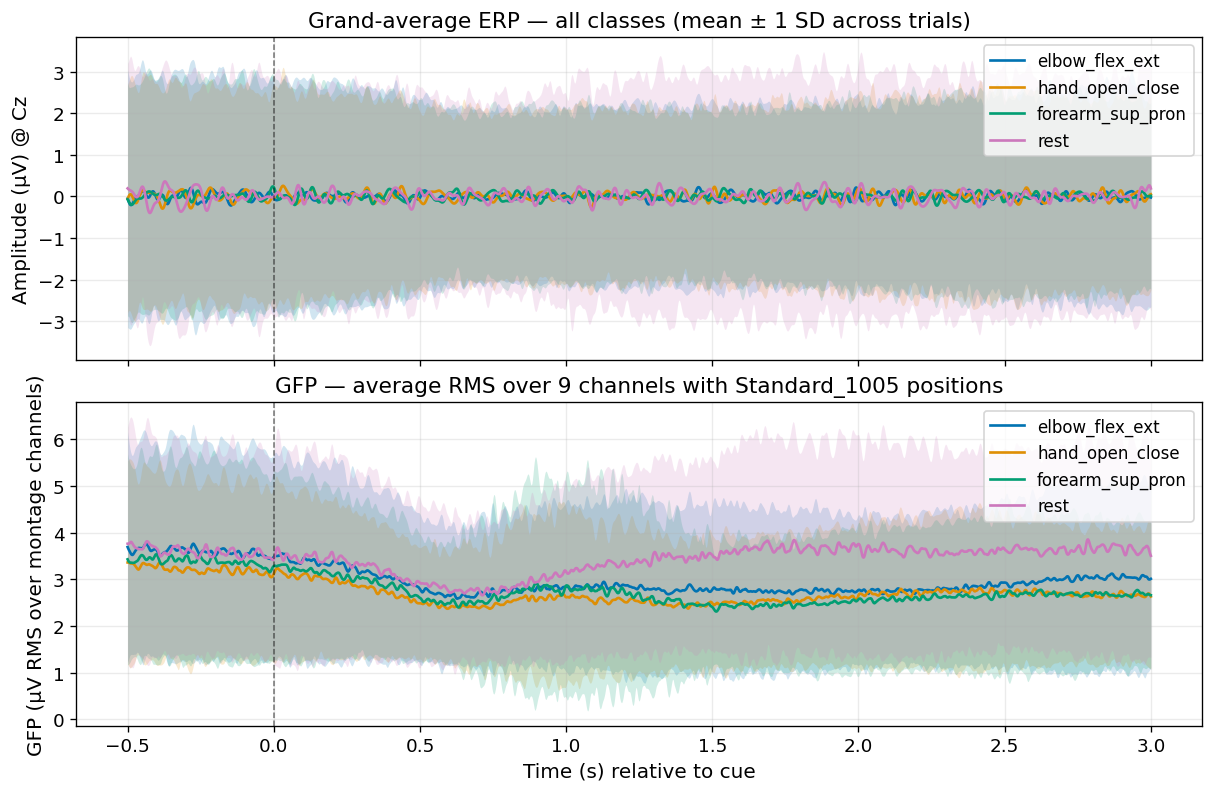

In [21]:

def erp_stats(data: np.ndarray, axis: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Mean and std across trials (or another axis)."""
    return np.mean(data, axis=axis), np.std(data, axis=axis, ddof=0)


PRIMARY_CH = "Cz"
if PRIMARY_CH not in ch_names:
    raise ValueError(
        f"Channel {PRIMARY_CH!r} not found. Pick one from ch_names[:20]={ch_names[:20]}"
    )

# Montage-aligned channels for GFP (exclude named channels absent from Standard_1005)
montage_1005 = mne.channels.make_standard_montage("standard_1005")
montage_present = montage_1005.ch_names
eeg_idxs = [i for i, name in enumerate(ch_names) if name in montage_present]
gfp_ch_names = [ch_names[i] for i in eeg_idxs]

X_flat = np.sqrt(np.mean(np.square(X[:, eeg_idxs, :]), axis=1))

# Color cycle: colorblind-friendly
colors = [
    "#0173b2",
    "#de8f05",
    "#029e73",
    "#cc78bc",
    "#ca9161",
    "#949494",
    "#ece133",
    "#56b4e9",
][: len(class_names)]

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)

ax = axes[0]
ci = ch_names.index(PRIMARY_CH)
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    m, s = erp_stats(X[mask, ci, :], axis=0)
    color = colors[k % len(colors)]
    ax.plot(times_s, m * 1e6, color=color, linewidth=1.6, label=name)
    ax.fill_between(times_s, (m - s) * 1e6, (m + s) * 1e6, color=color, alpha=0.18, linewidth=0)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_ylabel(f"Amplitude (µV) @ {PRIMARY_CH}")
ax.set_title("Grand-average ERP — all classes (mean ± 1 SD across trials)")
ax.legend(frameon=True, loc="upper right")

ax = axes[1]
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    m, s = erp_stats(X_flat[mask], axis=0)
    color = colors[k % len(colors)]
    ax.plot(times_s, m * 1e6, color=color, linewidth=1.6, label=name)
    ax.fill_between(times_s, (m - s) * 1e6, (m + s) * 1e6, color=color, alpha=0.18, linewidth=0)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_xlabel("Time (s) relative to cue")
ax.set_ylabel("GFP (µV RMS over montage channels)")
ax.set_title(
    f"GFP — average RMS over {len(gfp_ch_names)} channels with Standard_1005 positions"
)
ax.legend(frameon=True, loc="upper right")

plt.show()

### Midline strip (optional)

Quick view of **Fz–FCz–Cz–CPz–Pz** with the same mean ± SD convention; each row is one electrode, all classes overlaid.

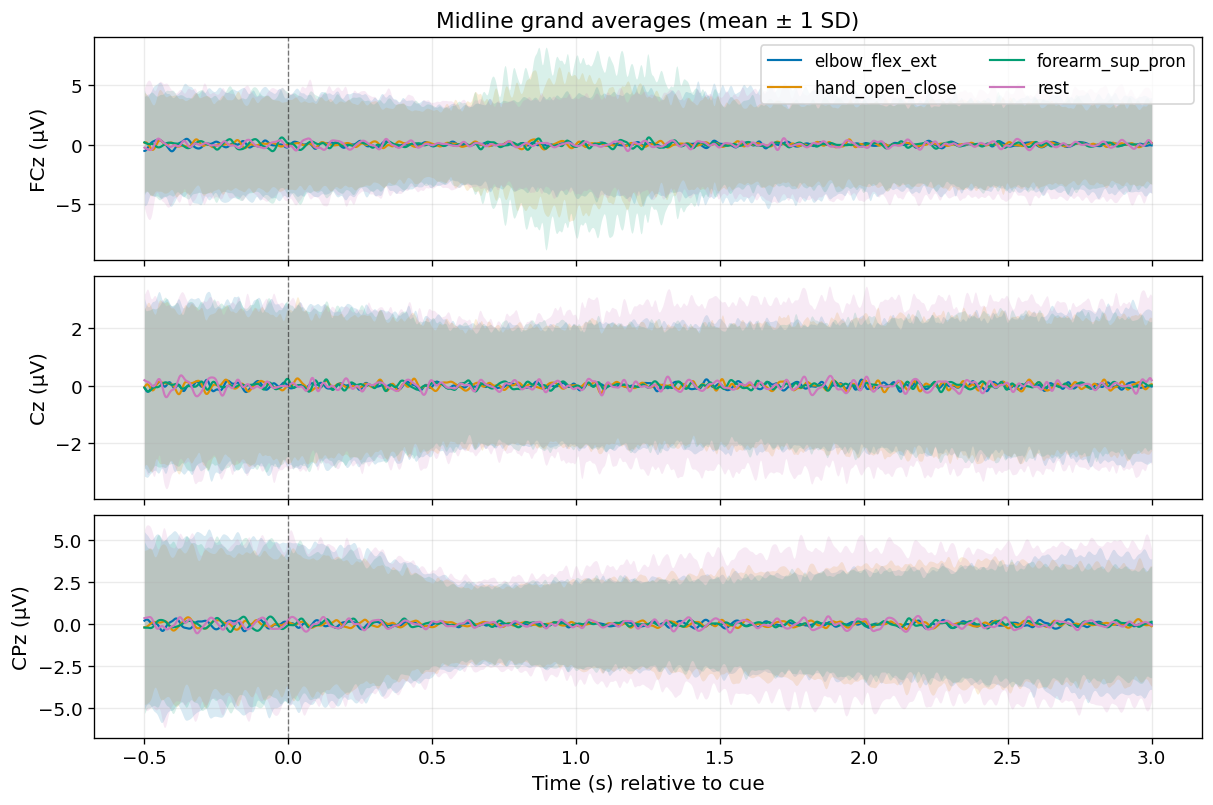

In [22]:

midline = [c for c in ["Fz", "FCz", "Cz", "CPz", "Pz"] if c in ch_names]
if len(midline) < 2:
    print("Few midline labels found; skip strip plot.")
else:
    nrows = len(midline)
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 2.2 * nrows), sharex=True, constrained_layout=True)
    if nrows == 1:
        axes = [axes]
    for ax, ch in zip(axes, midline, strict=True):
        ci = ch_names.index(ch)
        for k, name in enumerate(class_names):
            mask = y == k
            if not np.any(mask):
                continue
            m, s = erp_stats(X[mask, ci, :], axis=0)
            color = colors[k % len(colors)]
            ax.plot(times_s, m * 1e6, color=color, linewidth=1.3, label=name)
            ax.fill_between(times_s, (m - s) * 1e6, (m + s) * 1e6, color=color, alpha=0.15, linewidth=0)
        ax.axvline(0.0, color="k", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.set_ylabel(f"{ch} (µV)")
    axes[0].set_title("Midline grand averages (mean ± 1 SD)")
    axes[0].legend(ncol=2, loc="upper right", frameon=True)
    axes[-1].set_xlabel("Time (s) relative to cue")
    plt.show()

---
## Electrode-level activity in a post-cue window

We summarize each trial and channel with **root-mean-square (RMS) voltage** in a **post-cue interval** (default 0.3–2.0 s; edit `T_POST` below). That is a simple, movement-wide proxy for “how active” each electrode was during sustained motor preparation/execution imagery relative to cue onset.

Baseline **per trial** is subtracted using the RMS in **`T_BASE`** (defaults to full pre-cue epoch), so rankings emphasize **above-baseline engagement**.

We then report:

- **Mann–Whitney U** independent-sample tests (**movement vs REST**) channel-wise with **Bonferroni** adjustment for exploratory screening (movement and REST subsets are sampled to the **same cardinality** each run for fairness, but trials are **not** paired trial-by-trial).
- Tables of the **strongest electrodes** per movement class.
- **Topographies** on the scalp for (a) class means and (b) **movement minus rest** contrasts using the same RMS feature.

In [23]:

# Post-cue and baseline windows relative to cue (seconds)
T_POST = (0.3, 2.0)
T_BASE = (tmin, 0.0)


def slice_time(t_low: float, t_high: float) -> tuple[int, int]:
    """Inclusive low, exclusive upper bound in sample indices aligned to times_s."""
    i0 = int(np.searchsorted(times_s, t_low, side="left"))
    i1 = int(np.searchsorted(times_s, t_high, side="right"))
    i0 = max(0, min(i0, n_times - 1))
    i1 = max(i0 + 1, min(i1, n_times))
    return i0, i1


def trial_channel_rms(data: np.ndarray, t0: int, t1: int) -> np.ndarray:
    """data: (trials, ch, time) -> (trials, ch) RMS in [t0, t1)."""
    seg = data[:, :, t0:t1]
    return np.sqrt(np.mean(np.square(seg), axis=2))


i_post0, i_post1 = slice_time(T_POST[0], T_POST[1])
i_b0, i_b1 = slice_time(T_BASE[0], T_BASE[1])

rms_post_full = trial_channel_rms(X, i_post0, i_post1)
rms_base_full = trial_channel_rms(X, i_b0, i_b1)

# Montage-backed subset for topography (Standard_1005 positions)
rms_post = rms_post_full[:, eeg_idxs]
rms_base = rms_base_full[:, eeg_idxs]

rest_id = len(class_names) - 1 if class_names[-1].lower().startswith("rest") else None
if rest_id is None:
    rest_keys = [i for i, n in enumerate(class_names) if "rest" in n.lower()]
    rest_id = rest_keys[0] if rest_keys else None


def mannwhitney_bonferroni(x_move: np.ndarray, x_rest: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Two-sided MWU per channel; Bonferroni-adjusted p-values."""
    n_ch = x_move.shape[1]
    p_raw = np.empty(n_ch, dtype=float)
    for c in range(n_ch):
        a = x_move[:, c]
        b = x_rest[:, c]
        if np.allclose(a, b):
            p_raw[c] = 1.0
        else:
            _, p_raw[c] = mannwhitneyu(a, b, alternative="two-sided")
    return p_raw, np.minimum(p_raw * n_ch, 1.0)


# Equal-sized independent draws for exploratory stats
rng = np.random.default_rng(0)
TOP_N = 8

ranked_tables: dict[str, np.ndarray] = {}
contrasts: dict[str, np.ndarray] = {}

if rest_id is None:
    print("No REST label found; skipping motion-vs-rest inference.")
else:
    feats = rms_post - rms_base
    mask_rest_full = y == rest_id

    for k, name in enumerate(class_names):
        if k == rest_id:
            continue
        mask_m = y == k
        n_m = int(mask_m.sum())
        n_r = int(mask_rest_full.sum())
        n_pair = min(n_m, n_r)
        idx_m = rng.choice(np.where(mask_m)[0], size=n_pair, replace=False)
        idx_r = rng.choice(np.where(mask_rest_full)[0], size=n_pair, replace=False)

        xm = feats[idx_m]
        xr = feats[idx_r]
        mean_dx = xm.mean(axis=0)
        contrasts[name] = mean_dx

        _, p_adj = mannwhitney_bonferroni(xm, xr)
        ranking = np.argsort(-mean_dx)
        tbl = []
        for r in ranking[: TOP_N + 15]:
            tbl.append(
                (
                    gfp_ch_names[int(r)],
                    float(mean_dx[r] * 1e6),
                    float(p_adj[r]),
                    float(rms_post[idx_m][:, int(r)].mean() * 1e6),
                )
            )
        ranked_tables[name] = np.array(tbl, dtype=object)

    for name, tbl in ranked_tables.items():
        print("\n" + "═" * 72)
        print(
            f"Top electrodes — ΔRMS [{T_POST[0]:.2f},{T_POST[1]:.2f}] s minus baseline"
            f" [{T_BASE[0]:.2f},{T_BASE[1]:.2f}] s  |  {name}"
        )
        hdr = " rank  ch        ΔRMS_µV   Bonf_p   mean_post_µV"
        print(hdr)
        for i, row in enumerate(tbl[:TOP_N], start=1):
            ch, du, p, mp = row
            print(f" {i:3d}  {str(ch):8s}  {du:+8.2f}    {p:.3g}    {mp:10.2f}")


════════════════════════════════════════════════════════════════════════
Top electrodes — ΔRMS [0.30,2.00] s minus baseline [-0.50,0.00] s  |  elbow_flex_ext
 rank  ch        ΔRMS_µV   Bonf_p   mean_post_µV
   1  FC3          -0.09    0.0256          4.18
   2  FCz          -0.50    2.94e-10          3.48
   3  Cz           -0.58    3.03e-14          2.12
   4  C4           -0.71    3.27e-15          2.65
   5  FC4          -0.72    2.01e-11          2.96
   6  C3           -0.92    6e-25          2.43
   7  CP4          -0.99    1.47e-10          3.11
   8  CP3          -1.33    6.68e-26          2.76

════════════════════════════════════════════════════════════════════════
Top electrodes — ΔRMS [0.30,2.00] s minus baseline [-0.50,0.00] s  |  hand_open_close
 rank  ch        ΔRMS_µV   Bonf_p   mean_post_µV
   1  FCz          -0.24    2.17e-06          3.18
   2  Cz           -0.39    6.76e-07          2.06
   3  FC3          -0.43    0.000203          3.10
   4  FC4          -0.47   

### Scalp topographies (RMS feature)

Each panel shows spatial pattern of **trial-averaged** ΔRMS (post minus baseline): **movement classes** vs **REST alone**, plus **movement − REST** contrasts. Sensors are interpolated on a template sphere (**Standard_1005**).

Channels lacking template positions (`ProSupination`, etc.) are excluded from topography only.

(4,) 4


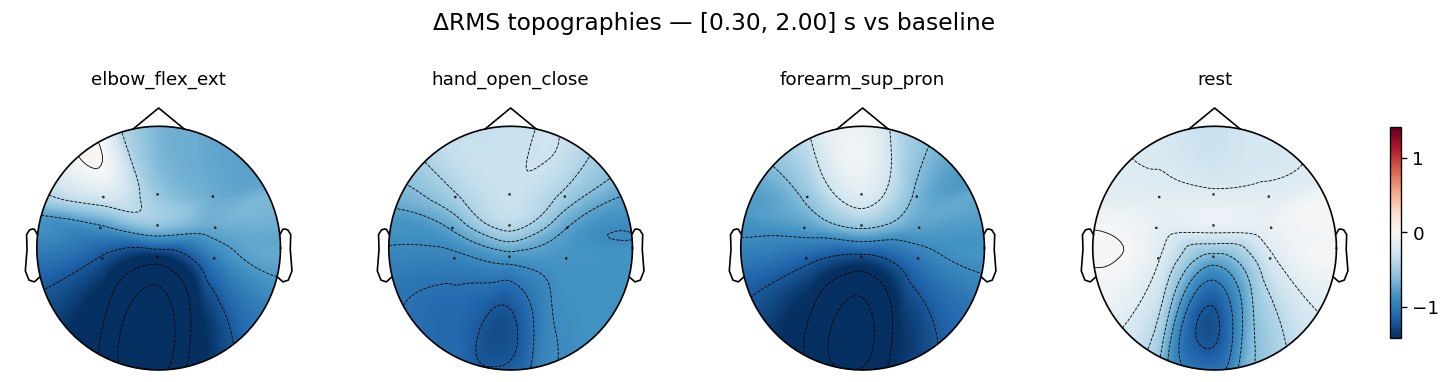

(3,) 3


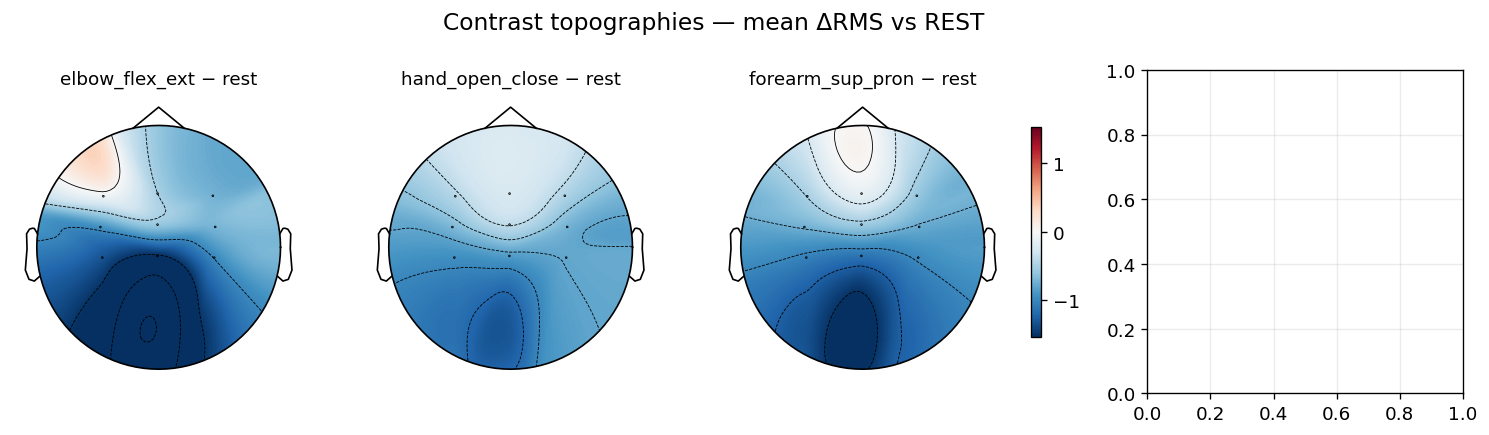

(4,) 4


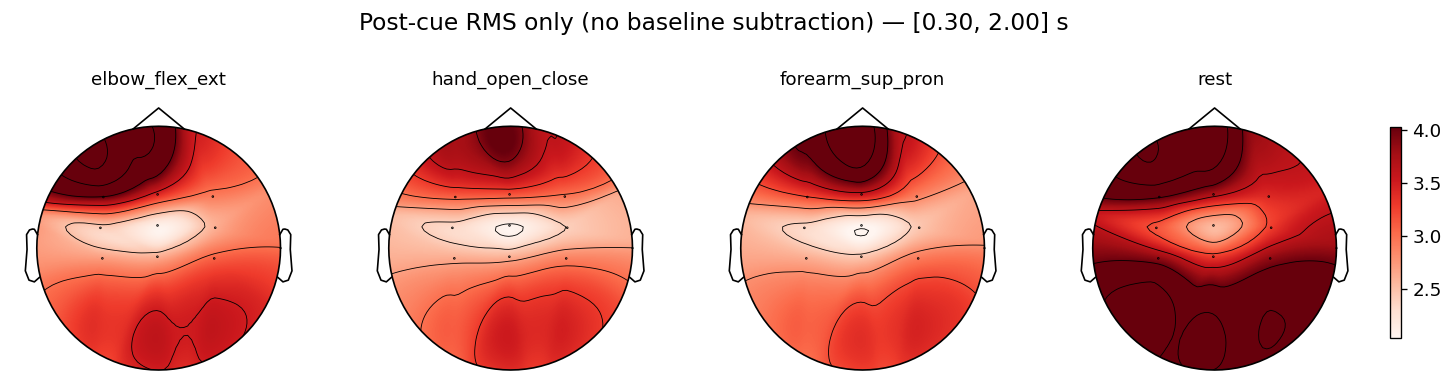

In [24]:

def topo_info(names: list[str], sfreq: float) -> mne.Info:
    info = mne.create_info(names, sfreq, ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1005")
    info.set_montage(montage)
    return info


info_topo = topo_info(gfp_ch_names, sfreq)


def plot_topo_grid(
    fields: list[tuple[str, np.ndarray]],
    title: str,
    *,
    ncols: int = 3,
    symmetric_limits: bool = False,
    cbar_label: str = "µV",
):
    """Topomap grid with shared axes limits for comparability."""
    n = len(fields)
    if n == 0:
        print("No fields to plot; skip topomap grid.")
        return
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.9 * ncols, 3.5 * nrows))
    axes = np.atleast_2d(np.array(axes)).ravel()
    axes = axes[:n]  # Keep only needed axes; turn off extras below

    vmin = vmax = None
    mats = np.stack([np.asarray(f[1], dtype=float).ravel() for f in fields], axis=0)
    vmin, vmax = float(np.nanmin(mats)), float(np.nanmax(mats))
    if symmetric_limits:
        mag = max(abs(vmin), abs(vmax)) or 1.0
        vmin, vmax = -mag, mag

    for ax in axes[n:]:
        ax.set_axis_off()

    ims = []
    print(axes.shape, len(fields))
    for ax, (subtitle, vals) in zip(axes, fields, strict=True):
        vlim = {"vlim": (vmin, vmax)} if vmin != vmax else {}
        im, _ = mne.viz.plot_topomap(
            np.asarray(vals, dtype=float), info_topo, show=False, axes=ax, **vlim
        )
        ax.set_title(subtitle, fontsize=11)
        ims.append(im)

    fig.suptitle(title, fontsize=14, y=1.02)
    cbar = fig.colorbar(
        ims[0], ax=list(axes[:n]), shrink=0.65, fraction=0.05, pad=0.02
    )
    cbar.ax.set_label(cbar_label)
    plt.show()


feats_all = rms_post - rms_base
fields_class: list[tuple[str, np.ndarray]] = []
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    fields_class.append((name, np.mean(feats_all[mask], axis=0) * 1e6))


plot_topo_grid(
    fields_class,
    title=f"ΔRMS topographies — [{T_POST[0]:.2f}, {T_POST[1]:.2f}] s vs baseline",
    symmetric_limits=True,
    cbar_label="µV RMS (Δ post − baseline)",
    ncols=4
)

if rest_id is not None and contrasts:
    fields_contrast = [
        (f"{m} − {class_names[rest_id]}", contrasts[m] * 1e6) for m in contrasts
    ]
    plot_topo_grid(
        fields_contrast,
        title="Contrast topographies — mean ΔRMS vs REST",
        symmetric_limits=True,
        cbar_label="µV RMS contrast",
        ncols=4
    )

fields_abs: list[tuple[str, np.ndarray]] = []
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    fields_abs.append((name, np.mean(rms_post[mask], axis=0) * 1e6))

plot_topo_grid(
    fields_abs,
    title=(
        "Post-cue RMS only (no baseline subtraction)"
        f" — [{T_POST[0]:.2f}, {T_POST[1]:.2f}] s"
    ),
    symmetric_limits=False,
    cbar_label="µV RMS (post window)",
    ncols=4
)

